# Второй блок. Логистическая регрессия и стратегия One-vs-Rest

### Импорт библиотек

In [ ]:
pip install scikit-learn matplotlib numpy pandas


In [15]:
import pandas as pd # Работа с csv данными
import numpy as np 
import matplotlib.pyplot as plt # Построение графиков
from sklearn.preprocessing import StandardScaler, label_binarize # Стандартизация признаков, преобразование меток в бинарный вид
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier # Приведение из бинарного вида к задаче с многими классами (0-5)
from sklearn.metrics import ( classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score ) # Метрики
import joblib # Сохранение модели
import time

### Подгрузка подготовленных признаков для обучения моделей

In [ ]:
train_df = pd.read_csv("features_train.csv")
test_df = pd.read_csv("features_test.csv")
# Разделяем входные данные и соответствующие классы
X_train = train_df.drop("Activity", axis=1) # Матрица признаков с удалением 1 колонки (т.е. номер класса)
y_train = train_df["Activity"] # Целевая переменная
X_test = test_df.drop("Activity", axis=1)
y_test = test_df["Activity"]

### Стандартизация признаков 

In [18]:
standarter = StandardScaler()
X_train_standart = standarter.fit_transform(X_train)
X_test_standart = standarter.transform(X_test) # Не пересчитываем параметры на тестовых данных

### Обучение логистической регрессиии со стратегией One-vs-Rest

In [ ]:
base = LogisticRegression(
    solver = "lbfgs", # Алгоритм для нахождения лучших параметров
    class_weight = "balanced", # В связи с неравномерностью количества данных по рахным классам
    random_state = 42 # Фиксируем рандомайзер
)
model = OneVsRestClassifier(base)
model.fit(X_train_standart, y_train) # Обучение

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...ndom_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](6,)","[0,1,2,3,4,5]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre...ndom_state=42), LogisticRegre...ndom_state=42), LogisticRegre...ndom_state=42), LogisticRegre...ndom_state=42), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,24
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'


### Предсказание по тествовым данным и замер времени предсказания нового примера (среднее значение)

In [ ]:
start_time = time.perf_counter()
y_pred = model.predict(X_test_standart)
all_time = (time.perf_counter()-start_time)*1000  # в миллисекундах
avg_time = all_time / len(y_test) 

### Сохранение модели

In [21]:
joblib.dump(model, "model.pkl")

['model.pkl']

### Метрики базавой модели
#### Стандартный Precision | Recall | F1-score, Accuracy, F1-Score(macro), Время инференса, Матрица ошибок (для сравнения между похожими классами)

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.41      0.48      0.44       657
           1       0.88      0.83      0.85      2078
           2       0.88      0.79      0.84       328
           3       0.79      1.00      0.88       265
           4       0.50      0.41      0.45       969
           5       0.81      0.84      0.82      3106

    accuracy                           0.75      7403
   macro avg       0.71      0.73      0.71      7403
weighted avg       0.75      0.75      0.75      7403



In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (test.csv): {acc}")

Accuracy for test.csv: 0.7537484803458058


In [23]:
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"F1-score (macro): {f1_macro}")

F1-score (macro): 0.7148049210140619


In [24]:
print(f"Avg inference time: {avg_time:} 10^(-3)*second ")

Avg inference time: 0.00043980818527156754 10^(-3)*second 


In [27]:
weights = np.array([i.coef_[0] for i in model.estimators_])
feature_naz = X_train.columns
print(pd.DataFrame(weights, columns=feature_naz, index=[f"Class {i}" for i in model.classes_]))

           x_mean     x_var     x_max     x_min  x_energy     x_zcr  \
Class 0  0.381156 -5.408017  2.986719 -3.600972 -0.971996  0.051731   
Class 1  0.311191  2.640841 -0.579555 -0.502951 -0.687403  0.020854   
Class 2  0.057154 -0.924048 -0.410751  0.761931 -0.232724  0.481852   
Class 3 -0.947051  0.648319 -0.340682  0.668780 -1.070453 -0.368301   
Class 4 -0.148337 -3.331757  1.169969 -1.251407 -0.613780 -0.268124   
Class 5 -0.779579 -1.953688  0.315257  1.600414  1.093463  0.151878   

         x_spectral_energy  x_dominant_freq    y_mean     y_var  ...  \
Class 0           0.387062         0.378670 -2.243577 -4.513673  ...   
Class 1          -1.583011         0.494008  0.686389  4.792626  ...   
Class 2          -0.013900        -0.729400  0.506484 -2.928321  ...   
Class 3          -1.469650        -0.527632  7.372034 -1.540705  ...   
Class 4           0.220628         0.095959  1.732083 -3.317005  ...   
Class 5           1.873114        -0.346775 -1.118956 -3.118729  ...  

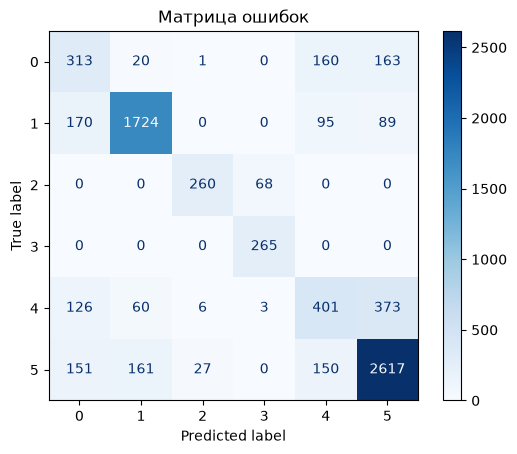

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Матрица ошибок")
plt.show()